#1 — Imports & Config

In [29]:
# =========================================================
# 1 — Imports & Config
# =========================================================

import os
import random
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================================================
# Reproducibility / Random Seed
# =========================================================
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# ---------- file paths ----------
SALES_FILE = "sales.csv"

# ---------- targets ----------
TARGETS = ["Revenue", "COGS"]

# ---------- feature config ----------
TARGET_LAGS = [1, 2, 3, 7, 14, 21, 28, 56, 90, 182, 365]
ROLL_WINDOWS = [7, 14, 28, 56]

# ---------- CV folds ----------
FOLDS = [
    ("2019-12-31", "2020-01-01", "2020-06-30"),
    ("2020-06-30", "2020-07-01", "2020-12-31"),
    ("2021-06-30", "2021-07-01", "2021-12-31"),
    ("2022-06-30", "2022-07-01", "2022-12-31"),
]

# ---------- model params ----------
MODEL_PARAMS = {
    "loss": "squared_error",
    "learning_rate": 0.03,
    "max_depth": 6,
    "max_iter": 500,
    "min_samples_leaf": 20,
    "l2_regularization": 0.1,
    "random_state": SEED
}

#2 — Load & Inspect Data

Shape: (3833, 3)
Columns: ['Date', 'Revenue', 'COGS']
Date range: 2012-07-04 → 2022-12-31

        Date      Revenue         COGS
0 2012-07-04 5,123,547.94 3,982,991.19
1 2012-07-05 2,751,773.45 2,150,580.23
2 2012-07-06 3,054,029.42 2,517,632.84
3 2012-07-07 2,667,930.94 2,108,246.62
4 2012-07-08 2,360,851.90 1,808,622.79

           Date      Revenue         COGS
3828 2022-12-27 2,100,553.66 2,184,872.24
3829 2022-12-28 3,448,729.20 3,513,621.00
3830 2022-12-29 3,083,944.33 3,170,787.10
3831 2022-12-30 2,884,668.76 3,022,292.15
3832 2022-12-31 2,383,037.48 2,279,288.13

Missing values:
Date       0
Revenue    0
COGS       0
dtype: int64

After reindex:
Shape: (3833, 3)
Date range: 2012-07-04 → 2022-12-31


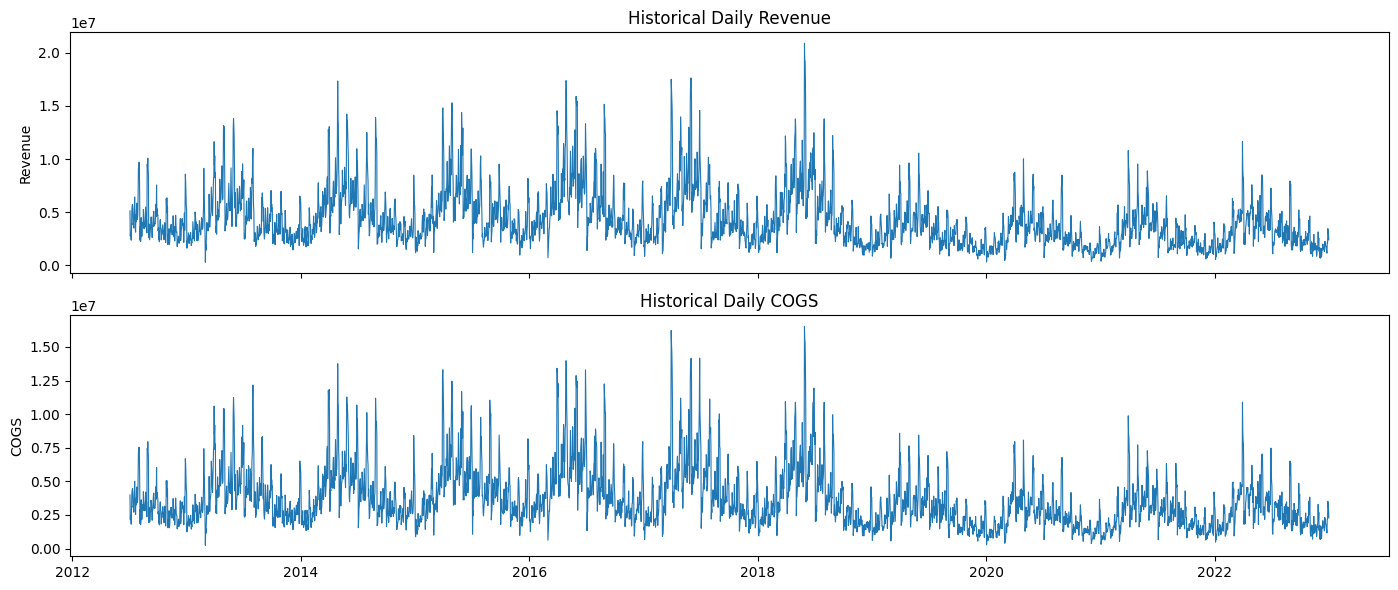

In [30]:
# =========================================================
# 2 — Load & Inspect Data
# =========================================================

sales = pd.read_csv(SALES_FILE, parse_dates=["Date"])
sales = sales.sort_values("Date").reset_index(drop=True)

print("Shape:", sales.shape)
print("Columns:", sales.columns.tolist())
print("Date range:", sales["Date"].min().date(), "→", sales["Date"].max().date())
print()
print(sales.head())
print()
print(sales.tail())

# kiểm tra missing
print("\nMissing values:")
print(sales.isna().sum())

# reindex về daily series đầy đủ
full_dates = pd.date_range(sales["Date"].min(), sales["Date"].max(), freq="D")
sales = (
    sales.set_index("Date")
         .reindex(full_dates)
         .rename_axis("Date")
         .reset_index()
)

# fill missing nếu có
for col in ["Revenue", "COGS"]:
    sales[col] = pd.to_numeric(sales[col], errors="coerce")
    sales[col] = sales[col].interpolate().ffill().bfill()

print("\nAfter reindex:")
print("Shape:", sales.shape)
print("Date range:", sales["Date"].min().date(), "→", sales["Date"].max().date())

# plot nhanh
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(sales["Date"], sales["Revenue"], lw=0.8)
axes[0].set_title("Historical Daily Revenue")
axes[0].set_ylabel("Revenue")

axes[1].plot(sales["Date"], sales["COGS"], lw=0.8)
axes[1].set_title("Historical Daily COGS")
axes[1].set_ylabel("COGS")

plt.tight_layout()
plt.show()

#3 — Feature Engineering

In [31]:
# =========================================================
# 3 — Feature Engineering
# =========================================================

def add_date_features(df_in: pd.DataFrame) -> pd.DataFrame:
    df = df_in.copy()

    df["dayofweek"] = df["Date"].dt.dayofweek
    df["dayofmonth"] = df["Date"].dt.day
    df["dayofyear"] = df["Date"].dt.dayofyear
    df["weekofyear"] = df["Date"].dt.isocalendar().week.astype(int)
    df["month"] = df["Date"].dt.month
    df["quarter"] = df["Date"].dt.quarter
    df["year"] = df["Date"].dt.year

    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)
    df["is_month_start"] = df["Date"].dt.is_month_start.astype(int)
    df["is_month_end"] = df["Date"].dt.is_month_end.astype(int)

    df["days_from_start"] = (df["Date"] - df["Date"].min()).dt.days

    # cyclical encoding
    df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
    df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)

    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    df["doy_sin"] = np.sin(2 * np.pi * df["dayofyear"] / 365.25)
    df["doy_cos"] = np.cos(2 * np.pi * df["dayofyear"] / 365.25)

    # payday proxy
    df["is_early_month"] = df["dayofmonth"].between(1, 5).astype(int)
    df["is_late_month"] = df["dayofmonth"].between(25, 31).astype(int)

    return df


def add_lag_roll_features(df_in: pd.DataFrame, target_col: str) -> pd.DataFrame:
    df = df_in.copy()

    for lag in TARGET_LAGS:
        df[f"{target_col}_lag_{lag}"] = df[target_col].shift(lag)

    shifted = df[target_col].shift(1)

    for w in ROLL_WINDOWS:
        df[f"{target_col}_roll_mean_{w}"] = shifted.rolling(w).mean()
        df[f"{target_col}_roll_std_{w}"] = shifted.rolling(w).std()
        df[f"{target_col}_roll_min_{w}"] = shifted.rolling(w).min()
        df[f"{target_col}_roll_max_{w}"] = shifted.rolling(w).max()

    df[f"{target_col}_ewm_7"] = shifted.ewm(span=7, adjust=False).mean()
    df[f"{target_col}_ewm_28"] = shifted.ewm(span=28, adjust=False).mean()

    return df


def make_features(df_in: pd.DataFrame, target_col: str) -> pd.DataFrame:
    df = df_in.copy()
    df = add_date_features(df)
    df = add_lag_roll_features(df, target_col)
    return df


# tạo feature thử cho Revenue
feature_df_revenue = make_features(sales.copy(), "Revenue")
feature_df_cogs = make_features(sales.copy(), "COGS")

print("Revenue feature shape:", feature_df_revenue.shape)
print("COGS feature shape:", feature_df_cogs.shape)

print("\nSample Revenue features:")
display(feature_df_revenue.head())

print("\nSample COGS features:")
display(feature_df_cogs.head())

Revenue feature shape: (3833, 51)
COGS feature shape: (3833, 51)

Sample Revenue features:


,Date,Revenue,COGS,dayofweek,dayofmonth,dayofyear,weekofyear,month,quarter,year,...,Revenue_roll_mean_28,Revenue_roll_std_28,Revenue_roll_min_28,Revenue_roll_max_28,Revenue_roll_mean_56,Revenue_roll_std_56,Revenue_roll_min_56,Revenue_roll_max_56,Revenue_ewm_7,Revenue_ewm_28
0,2012-07-04,"5,123,547.94","3,982,991.19",2,4,186,27,7,3,2012,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-07-05,"2,751,773.45","2,150,580.23",3,5,187,27,7,3,2012,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"5,123,547.94","5,123,547.94"
2,2012-07-06,"3,054,029.42","2,517,632.84",4,6,188,27,7,3,2012,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"4,530,604.32","4,959,977.29"
3,2012-07-07,"2,667,930.94","2,108,246.62",5,7,189,27,7,3,2012,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"4,161,460.59","4,828,532.61"
4,2012-07-08,"2,360,851.90","1,808,622.79",6,8,190,27,7,3,2012,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"3,788,078.18","4,679,525.59"



Sample COGS features:


,Date,Revenue,COGS,dayofweek,dayofmonth,dayofyear,weekofyear,month,quarter,year,...,COGS_roll_mean_28,COGS_roll_std_28,COGS_roll_min_28,COGS_roll_max_28,COGS_roll_mean_56,COGS_roll_std_56,COGS_roll_min_56,COGS_roll_max_56,COGS_ewm_7,COGS_ewm_28
0,2012-07-04,"5,123,547.94","3,982,991.19",2,4,186,27,7,3,2012,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-07-05,"2,751,773.45","2,150,580.23",3,5,187,27,7,3,2012,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"3,982,991.19","3,982,991.19"
2,2012-07-06,"3,054,029.42","2,517,632.84",4,6,188,27,7,3,2012,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"3,524,888.45","3,856,618.02"
3,2012-07-07,"2,667,930.94","2,108,246.62",5,7,189,27,7,3,2012,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"3,273,074.55","3,764,274.21"
4,2012-07-08,"2,360,851.90","1,808,622.79",6,8,190,27,7,3,2012,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"2,981,867.57","3,650,065.42"


# 4 - Model Training (Best Ensemble Setup)

In [32]:
# =========================================================
# 4 — Final Model Setup
# Revenue final:
#   features = advanced + promo
#   model    = 0.70 * boosting + 0.30 * CatBoost
#   boosting = 0.55 * Tuned_XGB + 0.30 * LGB + 0.15 * Hist
#
# COGS final:
#   features = base features only
#   model    = 0.68 * Tuned_LGB + 0.22 * Hist + 0.10 * SeasonalNaive
# =========================================================

# If needed on Colab:
# !pip install lightgbm xgboost catboost -q

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    import lightgbm as lgb
    HAS_LGB = True
except:
    HAS_LGB = False

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except:
    HAS_XGB = False

try:
    from catboost import CatBoostRegressor
    HAS_CAT = True
except:
    HAS_CAT = False


# ---------- load required files ----------
sales = pd.read_csv("sales.csv", parse_dates=["Date"]).sort_values("Date").reset_index(drop=True)
promotions = pd.read_csv("promotions.csv", parse_dates=["start_date", "end_date"])
inventory = pd.read_csv("inventory.csv", parse_dates=["snapshot_date"])

# ---------- normalize sales ----------
full_dates = pd.date_range(sales["Date"].min(), sales["Date"].max(), freq="D")
sales = (
    sales.set_index("Date")
         .reindex(full_dates)
         .rename_axis("Date")
         .reset_index()
)

for col in ["Revenue", "COGS"]:
    sales[col] = pd.to_numeric(sales[col], errors="coerce").interpolate().ffill().bfill()

# ---------- build sales_compact ----------
promo_rows = []
for _, row in promotions.iterrows():
    if pd.isna(row["start_date"]) or pd.isna(row["end_date"]):
        continue

    dates = pd.date_range(row["start_date"], row["end_date"], freq="D")
    tmp = pd.DataFrame({
        "Date": dates,
        "promo_id": row["promo_id"],
        "discount_value": row["discount_value"],
        "stackable_flag": row["stackable_flag"] if "stackable_flag" in row else 0
    })
    promo_rows.append(tmp)

if len(promo_rows) > 0:
    promo_daily = pd.concat(promo_rows, ignore_index=True)
    promo_compact = promo_daily.groupby("Date", as_index=False).agg(
        active_promos=("promo_id", "nunique"),
        avg_discount_value=("discount_value", "mean"),
        stackable_promos=("stackable_flag", "sum")
    )
else:
    promo_compact = pd.DataFrame({"Date": sales["Date"].copy()})
    promo_compact["active_promos"] = 0.0
    promo_compact["avg_discount_value"] = 0.0
    promo_compact["stackable_promos"] = 0.0

promo_compact = (
    pd.DataFrame({"Date": sales["Date"]})
    .merge(promo_compact, on="Date", how="left")
    .sort_values("Date")
    .reset_index(drop=True)
)

for c in ["active_promos", "avg_discount_value", "stackable_promos"]:
    promo_compact[c] = pd.to_numeric(promo_compact[c], errors="coerce").fillna(0.0)

inv_compact = inventory.groupby("snapshot_date", as_index=False).agg(
    inv_fill_rate=("fill_rate", "mean"),
    inv_stockout_flag=("stockout_flag", "mean"),
    inv_days_of_supply=("days_of_supply", "mean")
).rename(columns={"snapshot_date": "Date"})

inv_compact = (
    pd.DataFrame({"Date": sales["Date"]})
    .merge(inv_compact, on="Date", how="left")
    .sort_values("Date")
    .reset_index(drop=True)
)

for c in ["inv_fill_rate", "inv_stockout_flag", "inv_days_of_supply"]:
    inv_compact[c] = pd.to_numeric(inv_compact[c], errors="coerce").ffill().bfill()

sales_compact = sales.merge(promo_compact, on="Date", how="left")
sales_compact = sales_compact.merge(inv_compact, on="Date", how="left")


# ---------- config ----------
FOLDS = [
    ("2019-12-31", "2020-01-01", "2020-06-30"),
    ("2020-06-30", "2020-07-01", "2020-12-31"),
    ("2021-06-30", "2021-07-01", "2021-12-31"),
    ("2022-06-30", "2022-07-01", "2022-12-31"),
]

TARGET_LAGS = [1, 2, 3, 7, 14, 21, 28, 56, 90, 182, 365]
ROLL_WINDOWS = [7, 14, 28, 56]
ADV_LAGS = [1, 2, 3, 7, 14, 21, 28, 56, 84, 90, 182, 364, 365]
ADV_ROLLS = [3, 7, 14, 21, 28, 56]
PROMO_ONLY_COLS = ["active_promos", "avg_discount_value", "stackable_promos"]

MODEL_PARAMS = {
    "loss": "squared_error",
    "learning_rate": 0.03,
    "max_depth": 6,
    "max_iter": 500,
    "min_samples_leaf": 20,
    "l2_regularization": 0.1,
    "random_state": 42
}

HIST_PARAMS = MODEL_PARAMS.copy()

LGB_PARAMS = {
    "objective": "regression",
    "learning_rate": 0.03,
    "n_estimators": 500,
    "max_depth": 6,
    "num_leaves": 31,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
    "reg_alpha": 0.0,
    "reg_lambda": 0.1,
    "random_state": 42,
    "verbosity": -1
}

TUNED_XGB_PARAMS_REVENUE = {
    "objective": "reg:squarederror",
    "learning_rate": 0.03,
    "n_estimators": 400,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_lambda": 1.0,
    "random_state": 42
}

TUNED_LGB_PARAMS_COGS = {
    "learning_rate": 0.05,
    "n_estimators": 400,
    "max_depth": 6,
    "num_leaves": 31,
    "subsample": 0.9,
    "colsample_bytree": 0.8,
    "reg_lambda": 1.0
}

CAT_PARAMS_REVENUE = {
    "loss_function": "RMSE",
    "depth": 6,
    "learning_rate": 0.03,
    "iterations": 500,
    "l2_leaf_reg": 3.0,
    "random_seed": 42,
    "verbose": 0
}


# ---------- helper metrics ----------
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


# ---------- param cleaners ----------
def clean_lgb_params(params: dict):
    p = params.copy()
    p.pop("objective", None)
    p.pop("random_state", None)
    p.pop("verbosity", None)
    return p

def clean_xgb_params(params: dict):
    p = params.copy()
    p.pop("objective", None)
    p.pop("random_state", None)
    return p


# ---------- model builders ----------
def build_hist_model():
    return HistGradientBoostingRegressor(**HIST_PARAMS)

def build_lgb_model():
    if not HAS_LGB:
        raise ImportError("Chưa cài lightgbm. Hãy chạy: !pip install lightgbm")
    return lgb.LGBMRegressor(
        objective="regression",
        random_state=42,
        verbosity=-1,
        **clean_lgb_params(LGB_PARAMS)
    )

def build_tuned_xgb_model_revenue():
    if not HAS_XGB:
        raise ImportError("Chưa cài xgboost. Hãy chạy: !pip install xgboost")
    return XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        **clean_xgb_params(TUNED_XGB_PARAMS_REVENUE)
    )

def build_tuned_lgb_model_cogs():
    if not HAS_LGB:
        raise ImportError("Chưa cài lightgbm. Hãy chạy: !pip install lightgbm")
    return lgb.LGBMRegressor(
        objective="regression",
        random_state=42,
        verbosity=-1,
        **clean_lgb_params(TUNED_LGB_PARAMS_COGS)
    )

def build_cat_model_revenue():
    if not HAS_CAT:
        raise ImportError("Chưa cài catboost. Hãy chạy: !pip install catboost")
    return CatBoostRegressor(**CAT_PARAMS_REVENUE)


# ---------- feature engineering ----------
def add_date_features(df_in: pd.DataFrame) -> pd.DataFrame:
    df = df_in.copy()
    df["dayofweek"] = df["Date"].dt.dayofweek
    df["dayofmonth"] = df["Date"].dt.day
    df["dayofyear"] = df["Date"].dt.dayofyear
    df["weekofyear"] = df["Date"].dt.isocalendar().week.astype(int)
    df["month"] = df["Date"].dt.month
    df["quarter"] = df["Date"].dt.quarter
    df["year"] = df["Date"].dt.year
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)
    df["is_month_start"] = df["Date"].dt.is_month_start.astype(int)
    df["is_month_end"] = df["Date"].dt.is_month_end.astype(int)
    df["days_from_start"] = (df["Date"] - df["Date"].min()).dt.days

    df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
    df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    df["doy_sin"] = np.sin(2 * np.pi * df["dayofyear"] / 365.25)
    df["doy_cos"] = np.cos(2 * np.pi * df["dayofyear"] / 365.25)

    df["is_early_month"] = df["dayofmonth"].between(1, 5).astype(int)
    df["is_late_month"] = df["dayofmonth"].between(25, 31).astype(int)
    return df

def add_lag_roll_features(df_in: pd.DataFrame, target_col: str) -> pd.DataFrame:
    df = df_in.copy()

    for lag in TARGET_LAGS:
        df[f"{target_col}_lag_{lag}"] = df[target_col].shift(lag)

    shifted = df[target_col].shift(1)
    for w in ROLL_WINDOWS:
        df[f"{target_col}_roll_mean_{w}"] = shifted.rolling(w).mean()
        df[f"{target_col}_roll_std_{w}"] = shifted.rolling(w).std()
        df[f"{target_col}_roll_min_{w}"] = shifted.rolling(w).min()
        df[f"{target_col}_roll_max_{w}"] = shifted.rolling(w).max()

    df[f"{target_col}_ewm_7"] = shifted.ewm(span=7, adjust=False).mean()
    df[f"{target_col}_ewm_28"] = shifted.ewm(span=28, adjust=False).mean()
    return df

def make_features(df_in: pd.DataFrame, target_col: str) -> pd.DataFrame:
    df = df_in.copy()
    df = add_date_features(df)
    df = add_lag_roll_features(df, target_col)
    return df

def add_date_features_advanced(df_in: pd.DataFrame) -> pd.DataFrame:
    return add_date_features(df_in)

def add_lag_roll_features_advanced(df_in: pd.DataFrame, col: str, prefix: str = None) -> pd.DataFrame:
    df = df_in.copy()
    p = prefix if prefix is not None else col

    for lag in ADV_LAGS:
        df[f"{p}_lag_{lag}"] = df[col].shift(lag)

    shifted = df[col].shift(1)

    for w in ADV_ROLLS:
        df[f"{p}_roll_mean_{w}"] = shifted.rolling(w).mean()
        df[f"{p}_roll_std_{w}"] = shifted.rolling(w).std()
        df[f"{p}_roll_min_{w}"] = shifted.rolling(w).min()
        df[f"{p}_roll_max_{w}"] = shifted.rolling(w).max()

    df[f"{p}_ewm_7"] = shifted.ewm(span=7, adjust=False).mean()
    df[f"{p}_ewm_28"] = shifted.ewm(span=28, adjust=False).mean()
    return df

def add_target_advanced_features(df_in: pd.DataFrame, target_col: str) -> pd.DataFrame:
    df = df_in.copy()

    if f"{target_col}_lag_7" in df.columns and f"{target_col}_lag_14" in df.columns:
        df[f"{target_col}_ratio_lag7_lag14"] = df[f"{target_col}_lag_7"] / (df[f"{target_col}_lag_14"] + 1e-6)

    if f"{target_col}_lag_28" in df.columns and f"{target_col}_lag_56" in df.columns:
        df[f"{target_col}_ratio_lag28_lag56"] = df[f"{target_col}_lag_28"] / (df[f"{target_col}_lag_56"] + 1e-6)

    if f"{target_col}_roll_mean_7" in df.columns and f"{target_col}_roll_mean_28" in df.columns:
        df[f"{target_col}_ratio_roll7_roll28"] = df[f"{target_col}_roll_mean_7"] / (df[f"{target_col}_roll_mean_28"] + 1e-6)

    if f"{target_col}_lag_1" in df.columns and f"{target_col}_lag_7" in df.columns:
        df[f"{target_col}_delta_1_7"] = df[f"{target_col}_lag_1"] - df[f"{target_col}_lag_7"]

    if f"{target_col}_lag_7" in df.columns and f"{target_col}_lag_28" in df.columns:
        df[f"{target_col}_delta_7_28"] = df[f"{target_col}_lag_7"] - df[f"{target_col}_lag_28"]

    if f"{target_col}_roll_mean_7" in df.columns and f"{target_col}_roll_mean_28" in df.columns:
        df[f"{target_col}_trend_roll7_28"] = df[f"{target_col}_roll_mean_7"] - df[f"{target_col}_roll_mean_28"]

    shifted = df[target_col].shift(1)
    df[f"{target_col}_same_dow_avg_4w"] = (
        shifted.groupby(df["dayofweek"]).transform(lambda s: s.rolling(4, min_periods=1).mean())
    )

    if all(f"{target_col}_lag_{k}" in df.columns for k in [7, 14, 21, 28]):
        df[f"{target_col}_same_dow_mean_4"] = (
            df[f"{target_col}_lag_7"] +
            df[f"{target_col}_lag_14"] +
            df[f"{target_col}_lag_21"] +
            df[f"{target_col}_lag_28"]
        ) / 4.0

    return df

def add_promotion_intensity_features(df_in: pd.DataFrame) -> pd.DataFrame:
    df = df_in.copy()
    promo_cols = ["active_promos", "avg_discount_value", "stackable_promos"]

    if all(c in df.columns for c in promo_cols):
        df["promo_intensity"] = df["active_promos"] * df["avg_discount_value"]
        df["promo_stack_share"] = df["stackable_promos"] / (df["active_promos"] + 1e-6)

        for c in ["promo_intensity", "promo_stack_share"]:
            df = add_lag_roll_features_advanced(df, c, prefix=c)

    return df

def make_features_advanced(df_in: pd.DataFrame, target_col: str, use_promo=False, use_inventory=False):
    df = df_in.copy()

    # =====================================================
    # FIX: nếu không dùng inventory thì loại toàn bộ inventory columns
    # Tránh để inv_fill_rate / inv_stockout_flag / inv_days_of_supply
    # lọt vào model khi use_inventory=False
    # =====================================================
    if not use_inventory:
        inv_cols = [c for c in df.columns if c.startswith("inv_")]
        if len(inv_cols) > 0:
            df = df.drop(columns=inv_cols)

    # =====================================================
    # Date + target lag/rolling features
    # =====================================================
    df = add_date_features_advanced(df)
    df = add_lag_roll_features_advanced(df, target_col, prefix=target_col)
    df = add_target_advanced_features(df, target_col)

    # =====================================================
    # Promotion features
    # Chỉ tạo promo features nếu use_promo=True
    # =====================================================
    if use_promo:
        for c in ["active_promos", "avg_discount_value", "stackable_promos"]:
            if c in df.columns:
                for lag in [1, 7, 14]:
                    df[f"{c}_lag_{lag}"] = df[c].shift(lag)

                shifted = df[c].shift(1)
                for w in [7, 28]:
                    df[f"{c}_roll_mean_{w}"] = shifted.rolling(w).mean()

        df = add_promotion_intensity_features(df)

    else:
        # Nếu không dùng promo thì drop promo raw columns để khỏi lọt vào model
        promo_cols = [
            "active_promos",
            "avg_discount_value",
            "stackable_promos",
            "promo_intensity",
            "promo_stack_share"
        ]
        promo_cols = [c for c in promo_cols if c in df.columns]
        if len(promo_cols) > 0:
            df = df.drop(columns=promo_cols)

    return df


print("sales shape:", sales.shape)
print("sales_compact shape:", sales_compact.shape)
display(sales_compact.head())

sales shape: (3833, 3)
sales_compact shape: (3833, 9)


,Date,Revenue,COGS,active_promos,avg_discount_value,stackable_promos,inv_fill_rate,inv_stockout_flag,inv_days_of_supply
0,2012-07-04,"5,123,547.94","3,982,991.19",0.00,0.00,0.00,0.97,0.67,93.25
1,2012-07-05,"2,751,773.45","2,150,580.23",0.00,0.00,0.00,0.97,0.67,93.25
2,2012-07-06,"3,054,029.42","2,517,632.84",0.00,0.00,0.00,0.97,0.67,93.25
3,2012-07-07,"2,667,930.94","2,108,246.62",0.00,0.00,0.00,0.97,0.67,93.25
4,2012-07-08,"2,360,851.90","1,808,622.79",0.00,0.00,0.00,0.97,0.67,93.25


# 5 — Time Series Cross Validation

In [33]:
!pip install catboost -q

In [34]:
# =========================================================
# CatBoost setup
# =========================================================

try:
    from catboost import CatBoostRegressor
    HAS_CAT = True
except ImportError:
    HAS_CAT = False

CAT_PARAMS_REVENUE = {
    "loss_function": "RMSE",
    "depth": 6,
    "learning_rate": 0.03,
    "iterations": 500,
    "l2_leaf_reg": 3.0,
    "random_seed": 42,
    "verbose": 0
}

def build_cat_model_revenue():
    if not HAS_CAT:
        raise ImportError("Chưa cài catboost. Hãy chạy: !pip install catboost rồi restart kernel/runtime.")
    return CatBoostRegressor(**CAT_PARAMS_REVENUE)

In [35]:
# =========================================================
# FIX — COGS ratio/regime feature builders
# =========================================================

def add_date_features_local(df_in: pd.DataFrame) -> pd.DataFrame:
    df = df_in.copy()
    df["dayofweek"] = df["Date"].dt.dayofweek
    df["dayofmonth"] = df["Date"].dt.day
    df["dayofyear"] = df["Date"].dt.dayofyear
    df["month"] = df["Date"].dt.month
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)
    df["days_from_start"] = (df["Date"] - df["Date"].min()).dt.days
    return df

def add_lag_roll_features_local(df_in: pd.DataFrame, target_col: str, lags=None, rolls=None) -> pd.DataFrame:
    df = df_in.copy()

    if lags is None:
        lags = [1, 7, 14, 28]
    if rolls is None:
        rolls = [7, 28]

    for lag in lags:
        df[f"{target_col}_lag_{lag}"] = df[target_col].shift(lag)

    shifted = df[target_col].shift(1)
    for w in rolls:
        df[f"{target_col}_roll_mean_{w}"] = shifted.rolling(w).mean()
        df[f"{target_col}_roll_std_{w}"] = shifted.rolling(w).std()

    df[f"{target_col}_ewm_7"] = shifted.ewm(span=7, adjust=False).mean()
    df[f"{target_col}_ewm_28"] = shifted.ewm(span=28, adjust=False).mean()

    return df

def make_features_cogs_enhanced_local(df_in: pd.DataFrame):
    df = df_in.copy()
    df = add_date_features_local(df)
    df = add_lag_roll_features_local(df, "COGS", lags=[1, 7, 14, 28], rolls=[7, 28])
    df = add_lag_roll_features_local(df, "Revenue", lags=[1, 7, 14, 28], rolls=[7, 28])

    if all(c in df.columns for c in ["Revenue_lag_7", "COGS_lag_7"]):
        df["gross_margin_lag_7"] = df["Revenue_lag_7"] - df["COGS_lag_7"]
        df["cogs_to_revenue_lag_7"] = df["COGS_lag_7"] / (df["Revenue_lag_7"] + 1e-6)

    if all(c in df.columns for c in ["Revenue_roll_mean_28", "COGS_roll_mean_28"]):
        df["gross_margin_roll_28"] = df["Revenue_roll_mean_28"] - df["COGS_roll_mean_28"]
        df["cogs_to_revenue_roll_28"] = df["COGS_roll_mean_28"] / (df["Revenue_roll_mean_28"] + 1e-6)

    for c in ["Revenue_outlier_flag", "COGS_outlier_flag"]:
        if c not in df.columns:
            df[c] = 0

    return df

def make_features_cogs_ratio_fast(df_in: pd.DataFrame):
    df = make_features_cogs_enhanced_local(df_in.copy())
    df["COGS_ratio_target"] = df["COGS"] / (df["Revenue"] + 1e-6)

    if all(c in df.columns for c in ["COGS_roll_mean_28", "Revenue_roll_mean_28"]):
        df["COGS_ratio_roll28_target"] = df["COGS_roll_mean_28"] / (df["Revenue_roll_mean_28"] + 1e-6)

    return df

In [36]:
# =========================================================
# FINAL CV — REVERT COGS TO OLD NON-LEAKY MODEL
# Revenue: giữ nguyên raw best model
# COGS: quay về model cũ
#        0.68 Tuned_LGB + 0.22 Hist + 0.10 SeasonalNaive
#        base features only
# =========================================================

def seasonal_naive_predict(history_df: pd.DataFrame, future_dates: pd.DatetimeIndex, target_col: str):
    hist = history_df.copy()
    hist["Date"] = pd.to_datetime(hist["Date"])
    hist = hist.sort_values("Date").drop_duplicates("Date")
    hist = hist.set_index("Date")[target_col].astype(float)

    if not isinstance(future_dates, pd.DatetimeIndex):
        future_dates = pd.DatetimeIndex(pd.to_datetime(future_dates))

    preds = []
    for d in future_dates:
        candidates = []
        for lag in [7, 14, 21, 28, 364, 365]:
            prev_d = d - pd.Timedelta(days=lag)
            if prev_d in hist.index:
                candidates.append(hist.loc[prev_d])

        if len(candidates) == 0:
            pred = float(hist.tail(7).mean())
        else:
            pred = float(np.mean(candidates))

        preds.append(max(pred, 0.0))

    return np.array(preds)


def fit_predict_revenue_final_components(feat_train: pd.DataFrame, feat_valid: pd.DataFrame):
    drop_cols = [c for c in ["Date", "Revenue", "COGS"] if c in feat_train.columns]

    X_train = feat_train.drop(columns=drop_cols).select_dtypes(include=[np.number]).copy()
    y_train = np.log1p(feat_train["Revenue"].clip(lower=0).values)

    X_valid = feat_valid.drop(columns=drop_cols).select_dtypes(include=[np.number]).copy()

    model_xgb = build_tuned_xgb_model_revenue()
    model_lgb = build_lgb_model()
    model_hist = build_hist_model()
    model_cat = build_cat_model_revenue()

    model_xgb.fit(X_train, y_train)
    model_lgb.fit(X_train, y_train)
    model_hist.fit(X_train, y_train)
    model_cat.fit(X_train, y_train)

    pred_xgb = np.clip(np.expm1(model_xgb.predict(X_valid)), 0, None)
    pred_lgb = np.clip(np.expm1(model_lgb.predict(X_valid)), 0, None)
    pred_hist = np.clip(np.expm1(model_hist.predict(X_valid)), 0, None)
    pred_cat = np.clip(np.expm1(model_cat.predict(X_valid)), 0, None)

    pred_boost = 0.55 * pred_xgb + 0.30 * pred_lgb + 0.15 * pred_hist
    pred_final = 0.70 * pred_boost + 0.30 * pred_cat
    return np.clip(pred_final, 0, None)


def fit_predict_cogs_old_components(feat_train: pd.DataFrame, feat_valid: pd.DataFrame):
    drop_cols = [c for c in ["Date", "Revenue", "COGS"] if c in feat_train.columns]

    X_train = feat_train.drop(columns=drop_cols).select_dtypes(include=[np.number]).copy()
    y_train = np.log1p(feat_train["COGS"].clip(lower=0).values)

    X_valid = feat_valid.drop(columns=drop_cols).select_dtypes(include=[np.number]).copy()

    model_lgb = build_tuned_lgb_model_cogs()
    model_hist = build_hist_model()

    model_lgb.fit(X_train, y_train)
    model_hist.fit(X_train, y_train)

    pred_lgb = np.clip(np.expm1(model_lgb.predict(X_valid)), 0, None)
    pred_hist = np.clip(np.expm1(model_hist.predict(X_valid)), 0, None)

    pred_boost = 0.68 * pred_lgb + 0.22 * pred_hist
    return np.clip(pred_boost, 0, None)


def time_series_cv_evaluate_final_revert_cogs(df_revenue: pd.DataFrame, df_cogs: pd.DataFrame, target_col: str):
    results = []

    for i, (train_end, valid_start, valid_end) in enumerate(FOLDS, start=1):

        # -------------------------------------------------
        # REVENUE = raw best model
        # -------------------------------------------------
        if target_col == "Revenue":
            train_df = df_revenue[df_revenue["Date"] <= pd.Timestamp(train_end)].copy()
            valid_df = df_revenue[
                (df_revenue["Date"] >= pd.Timestamp(valid_start)) &
                (df_revenue["Date"] <= pd.Timestamp(valid_end))
            ].copy()

            if len(train_df) < 300 or len(valid_df) == 0:
                continue

            combined = pd.concat([train_df, valid_df], axis=0).reset_index(drop=True)
            feat_df = make_features_advanced(combined, "Revenue", use_promo=True, use_inventory=False)

            feat_train = feat_df[feat_df["Date"] <= pd.Timestamp(train_end)].dropna().reset_index(drop=True)
            feat_valid = feat_df[
                (feat_df["Date"] >= pd.Timestamp(valid_start)) &
                (feat_df["Date"] <= pd.Timestamp(valid_end))
            ].dropna().reset_index(drop=True)

            if len(feat_train) == 0 or len(feat_valid) == 0:
                continue

            y_valid = feat_valid["Revenue"].values
            pred = fit_predict_revenue_final_components(feat_train, feat_valid)
            ensemble_name = "Revenue_Final_RawBest"

        # -------------------------------------------------
        # COGS = old non-leaky model
        # -------------------------------------------------
        elif target_col == "COGS":
            train_df = df_cogs[df_cogs["Date"] <= pd.Timestamp(train_end)].copy()
            valid_df = df_cogs[
                (df_cogs["Date"] >= pd.Timestamp(valid_start)) &
                (df_cogs["Date"] <= pd.Timestamp(valid_end))
            ].copy()

            if len(train_df) < 300 or len(valid_df) == 0:
                continue

            combined = pd.concat([train_df, valid_df], axis=0).reset_index(drop=True)
            feat_df = make_features(combined, "COGS")

            feat_train = feat_df[feat_df["Date"] <= pd.Timestamp(train_end)].dropna().reset_index(drop=True)
            feat_valid = feat_df[
                (feat_df["Date"] >= pd.Timestamp(valid_start)) &
                (feat_df["Date"] <= pd.Timestamp(valid_end))
            ].dropna().reset_index(drop=True)

            if len(feat_train) == 0 or len(feat_valid) == 0:
                continue

            y_valid = feat_valid["COGS"].values

            pred_boost = fit_predict_cogs_old_components(feat_train, feat_valid)
            pred_snaive = seasonal_naive_predict(
                train_df[["Date", "COGS"]].copy(),
                pd.DatetimeIndex(valid_df["Date"]),
                "COGS"
            )

            pred = np.clip(pred_boost + 0.10 * pred_snaive, 0, None)
            ensemble_name = "COGS_Final_OldModel"

        else:
            raise ValueError("target_col phải là 'Revenue' hoặc 'COGS'")

        results.append({
            "fold": i,
            "target": target_col,
            "ensemble": ensemble_name,
            "MAE": mean_absolute_error(y_valid, pred),
            "RMSE": rmse(y_valid, pred),
            "R2": r2_score(y_valid, pred)
        })

    return pd.DataFrame(results)


print("===== FINAL CV: REVENUE =====")
cv_rev_final = time_series_cv_evaluate_final_revert_cogs(sales_compact, sales, "Revenue")
display(cv_rev_final)
print("\nRevenue mean CV:")
display(cv_rev_final[["MAE", "RMSE", "R2"]].mean().to_frame().T)

print("\n===== FINAL CV: COGS =====")
cv_cogs_final = time_series_cv_evaluate_final_revert_cogs(sales_compact, sales, "COGS")
display(cv_cogs_final)
print("\nCOGS mean CV:")
display(cv_cogs_final[["MAE", "RMSE", "R2"]].mean().to_frame().T)

===== FINAL CV: REVENUE =====


,fold,target,ensemble,MAE,RMSE,R2
0,1,Revenue,Revenue_Final_RawBest,"627,520.40","895,465.94",0.75
1,2,Revenue,Revenue_Final_RawBest,"456,452.79","664,527.66",0.75
2,3,Revenue,Revenue_Final_RawBest,"426,357.24","570,502.04",0.68
3,4,Revenue,Revenue_Final_RawBest,"496,436.21","692,051.15",0.69



Revenue mean CV:


,MAE,RMSE,R2
0,"501,691.66","705,636.70",0.72



===== FINAL CV: COGS =====


,fold,target,ensemble,MAE,RMSE,R2
0,1,COGS,COGS_Final_OldModel,"494,790.53","699,474.08",0.79
1,2,COGS,COGS_Final_OldModel,"352,040.81","483,401.92",0.80
2,3,COGS,COGS_Final_OldModel,"419,860.37","586,462.60",0.71
3,4,COGS,COGS_Final_OldModel,"445,675.99","633,819.60",0.64



COGS mean CV:


,MAE,RMSE,R2
0,"428,091.92","600,789.55",0.73


# Drivers

In [37]:
# =========================================================
# 8 — Explainability: Permutation Importance + SHAP
# Fixed version + display 6 decimal places
# =========================================================

from sklearn.inspection import permutation_importance

try:
    import shap
    HAS_SHAP = True
except Exception:
    HAS_SHAP = False


def revenue_feature_importance_last_fold():
    train_end = "2022-06-30"
    valid_start = "2022-07-01"
    valid_end = "2022-12-31"

    train_df = sales_compact[sales_compact["Date"] <= pd.Timestamp(train_end)].copy()
    valid_df = sales_compact[
        (sales_compact["Date"] >= pd.Timestamp(valid_start)) &
        (sales_compact["Date"] <= pd.Timestamp(valid_end))
    ].copy()

    combined = pd.concat([train_df, valid_df], axis=0).reset_index(drop=True)

    # FIX: dùng make_features_advanced, không dùng make_features(... advanced=True)
    feat = make_features_advanced(
        combined,
        target_col="Revenue",
        use_promo=True,
        use_inventory=False
    )

    feat_train = feat[
        feat["Date"] <= pd.Timestamp(train_end)
    ].dropna().reset_index(drop=True)

    feat_valid = feat[
        (feat["Date"] >= pd.Timestamp(valid_start)) &
        (feat["Date"] <= pd.Timestamp(valid_end))
    ].dropna().reset_index(drop=True)

    drop_cols = [c for c in ["Date", "Revenue", "COGS"] if c in feat_train.columns]

    X_train = feat_train.drop(columns=drop_cols).select_dtypes(include=[np.number]).copy()
    y_train = np.log1p(feat_train["Revenue"].clip(lower=0).values)

    X_valid = feat_valid.drop(columns=drop_cols).select_dtypes(include=[np.number]).copy()
    y_valid = np.log1p(feat_valid["Revenue"].clip(lower=0).values)

    # align columns
    for c in X_train.columns:
        if c not in X_valid.columns:
            X_valid[c] = 0.0

    X_valid = X_valid[X_train.columns]

    # check inventory đã bị loại
    print("Inventory columns in X_train:")
    print([c for c in X_train.columns if c.startswith("inv_")])

    model_xgb = build_tuned_xgb_model_revenue()
    model_lgb = build_lgb_model()
    model_hist = build_hist_model()
    model_cat = build_cat_model_revenue()

    model_xgb.fit(X_train, y_train)
    model_lgb.fit(X_train, y_train)
    model_hist.fit(X_train, y_train)
    model_cat.fit(X_train, y_train)

    def permutation_df(model, X, y, name):
        result = permutation_importance(
            model,
            X,
            y,
            n_repeats=5,
            random_state=SEED,
            scoring="neg_mean_squared_error"
        )

        return pd.DataFrame({
            "feature": X.columns,
            f"imp_{name}": result.importances_mean
        })

    imp_all = (
        permutation_df(model_xgb, X_valid, y_valid, "xgb")
        .merge(permutation_df(model_lgb, X_valid, y_valid, "lgb"), on="feature", how="outer")
        .merge(permutation_df(model_hist, X_valid, y_valid, "hist"), on="feature", how="outer")
        .merge(permutation_df(model_cat, X_valid, y_valid, "cat"), on="feature", how="outer")
        .fillna(0)
    )

    imp_all["ensemble_importance"] = (
        0.385 * imp_all["imp_xgb"] +
        0.210 * imp_all["imp_lgb"] +
        0.105 * imp_all["imp_hist"] +
        0.300 * imp_all["imp_cat"]
    )

    imp_all = imp_all.sort_values(
        "ensemble_importance",
        ascending=False
    ).reset_index(drop=True)

    # =====================================================
    # Display 6 decimal places
    # =====================================================
    imp_cols = ["imp_xgb", "imp_lgb", "imp_hist", "imp_cat", "ensemble_importance"]

    print("\n===== TOP REVENUE DRIVERS: PERMUTATION IMPORTANCE =====")

    if "display" in globals():
        display(
            imp_all.head(20).style.format({
                c: "{:.6f}" for c in imp_cols if c in imp_all.columns
            })
        )
    else:
        print(imp_all.head(20).to_string(float_format=lambda x: f"{x:.6f}"))

    imp_all.to_csv("revenue_feature_importance.csv", index=False, float_format="%.6f")

    if HAS_SHAP:
        sample_X = X_valid.sample(min(300, len(X_valid)), random_state=SEED)

        explainer_xgb = shap.TreeExplainer(model_xgb)
        explainer_lgb = shap.TreeExplainer(model_lgb)
        explainer_cat = shap.TreeExplainer(model_cat)

        shap_xgb = explainer_xgb.shap_values(sample_X)
        shap_lgb = explainer_lgb.shap_values(sample_X)
        shap_cat = explainer_cat.shap_values(sample_X)

        # HistGradientBoosting bỏ khỏi SHAP để tránh lỗi version
        shap_ensemble = (
            0.385 * shap_xgb +
            0.210 * shap_lgb +
            0.300 * shap_cat
        ) / (0.385 + 0.210 + 0.300)

        shap_df = pd.DataFrame({
            "feature": sample_X.columns,
            "mean_abs_shap": np.abs(shap_ensemble).mean(axis=0)
        }).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

        print("\n===== TOP REVENUE DRIVERS: SHAP =====")

        if "display" in globals():
            display(
                shap_df.head(20).style.format({
                    "mean_abs_shap": "{:.6f}"
                })
            )
        else:
            print(shap_df.head(20).to_string(float_format=lambda x: f"{x:.6f}"))

        shap_df.to_csv("revenue_shap_importance.csv", index=False, float_format="%.6f")

    else:
        print("SHAP is not installed. Permutation importance has been saved instead.")

    return imp_all


importance_df = revenue_feature_importance_last_fold()

Inventory columns in X_train:
[]

===== TOP REVENUE DRIVERS: PERMUTATION IMPORTANCE =====
                       feature  imp_xgb   imp_lgb  imp_hist   imp_cat  ensemble_importance
0                Revenue_lag_1 0.057672  0.063030  0.070904  0.040720             0.055101
1                   dayofmonth 0.010964  0.015916  0.017450  0.009815             0.012340
2              Revenue_lag_365 0.005451  0.002424  0.002783  0.003995             0.004099
3              Revenue_lag_364 0.004207  0.003051  0.004739  0.002458             0.003495
4               is_early_month 0.001351  0.000102  0.000239  0.006347             0.002471
5    Revenue_ratio_lag28_lag56 0.002359  0.002018  0.002273  0.002066             0.002190
6            Revenue_delta_1_7 0.001144  0.001737  0.002526  0.002514             0.001824
7               Revenue_lag_14 0.002175  0.001863  0.001748  0.001334             0.001812
8                Revenue_lag_7 0.002296  0.002964  0.002069 -0.000133             0.001684


# 6 — Forecast Future Period

In [38]:
# =========================================================
# 6 — Final Forecast Future Period
# Revenue = Final RawBest Model
# COGS = Old Non-Leaky Model
# FIXED: recursive forecast không drop mất dòng future
# =========================================================

def fit_revenue_final_full(df_train: pd.DataFrame):
    full_feat = make_features_advanced(
        df_train.copy(),
        target_col="Revenue",
        use_promo=True,
        use_inventory=False
    )

    full_feat = full_feat.dropna().reset_index(drop=True)

    drop_cols = [c for c in ["Date", "Revenue", "COGS"] if c in full_feat.columns]

    X_train = full_feat.drop(columns=drop_cols).select_dtypes(include=[np.number]).copy()
    y_train = np.log1p(full_feat["Revenue"].clip(lower=0).values)

    model_xgb = build_tuned_xgb_model_revenue()
    model_lgb = build_lgb_model()
    model_hist = build_hist_model()
    model_cat = build_cat_model_revenue()

    model_xgb.fit(X_train, y_train)
    model_lgb.fit(X_train, y_train)
    model_hist.fit(X_train, y_train)
    model_cat.fit(X_train, y_train)

    return {
        "xgb": model_xgb,
        "lgb": model_lgb,
        "hist": model_hist,
        "cat": model_cat,
        "feature_cols": X_train.columns.tolist()
    }


def fit_cogs_old_full(df_train: pd.DataFrame):
    full_feat = make_features(df_train.copy(), target_col="COGS")
    full_feat = full_feat.dropna().reset_index(drop=True)

    drop_cols = [c for c in ["Date", "Revenue", "COGS"] if c in full_feat.columns]

    X_train = full_feat.drop(columns=drop_cols).select_dtypes(include=[np.number]).copy()
    y_train = np.log1p(full_feat["COGS"].clip(lower=0).values)

    model_lgb = build_tuned_lgb_model_cogs()
    model_hist = build_hist_model()

    model_lgb.fit(X_train, y_train)
    model_hist.fit(X_train, y_train)

    return {
        "lgb": model_lgb,
        "hist": model_hist,
        "feature_cols": X_train.columns.tolist()
    }


def make_next_X_from_last_row(feat_tmp: pd.DataFrame, feature_cols: list):
    """
    Lấy đúng dòng future cuối cùng để predict.
    Không dùng dropna toàn bộ vì future Revenue/COGS đang là NaN.
    """
    drop_cols = [c for c in ["Date", "Revenue", "COGS"] if c in feat_tmp.columns]

    X_next = feat_tmp.iloc[[-1]].drop(columns=drop_cols)
    X_next = X_next.select_dtypes(include=[np.number]).copy()

    for c in feature_cols:
        if c not in X_next.columns:
            X_next[c] = 0.0

    X_next = X_next[feature_cols]

    # Nếu còn NaN ở feature do thiếu rolling đầu kỳ thì fill bằng 0
    X_next = X_next.replace([np.inf, -np.inf], np.nan).fillna(0.0)

    return X_next


def recursive_forecast_revenue_final(
    df_train: pd.DataFrame,
    future_dates: pd.DatetimeIndex,
    promo_scenario: str = "carry_last"
):
    hist = df_train.copy().sort_values("Date").reset_index(drop=True)

    fitted = fit_revenue_final_full(hist)
    feature_cols = fitted["feature_cols"]

    preds = []

    for d in pd.DatetimeIndex(future_dates):
        new_row = {
            "Date": d,
            "Revenue": np.nan,
            "COGS": np.nan,
            "active_promos": 0.0,
            "avg_discount_value": 0.0,
            "stackable_promos": 0.0
        }

        if promo_scenario == "carry_last":
            for c in ["active_promos", "avg_discount_value", "stackable_promos"]:
                if c in hist.columns and hist[c].notna().sum() > 0:
                    new_row[c] = float(hist[c].dropna().iloc[-1])

        elif promo_scenario == "avg_28":
            for c in ["active_promos", "avg_discount_value", "stackable_promos"]:
                if c in hist.columns and hist[c].notna().sum() > 0:
                    new_row[c] = float(hist[c].dropna().tail(28).mean())

        tmp = pd.concat([hist, pd.DataFrame([new_row])], ignore_index=True)

        feat_tmp = make_features_advanced(
            tmp.copy(),
            target_col="Revenue",
            use_promo=True,
            use_inventory=False
        )

        X_next = make_next_X_from_last_row(feat_tmp, feature_cols)

        pred_xgb = np.expm1(fitted["xgb"].predict(X_next))[0]
        pred_lgb = np.expm1(fitted["lgb"].predict(X_next))[0]
        pred_hist = np.expm1(fitted["hist"].predict(X_next))[0]
        pred_cat = np.expm1(fitted["cat"].predict(X_next))[0]

        pred_boost = 0.55 * pred_xgb + 0.30 * pred_lgb + 0.15 * pred_hist
        pred_final = 0.70 * pred_boost + 0.30 * pred_cat
        pred_final = max(float(pred_final), 0.0)

        preds.append(pred_final)

        new_row["Revenue"] = pred_final
        hist = pd.concat([hist, pd.DataFrame([new_row])], ignore_index=True)

    return np.array(preds)


def recursive_forecast_cogs_old_final(
    df_train: pd.DataFrame,
    future_dates: pd.DatetimeIndex
):
    hist = df_train.copy().sort_values("Date").reset_index(drop=True)

    fitted = fit_cogs_old_full(hist)
    feature_cols = fitted["feature_cols"]

    preds = []

    for d in pd.DatetimeIndex(future_dates):
        new_row = {
            "Date": d,
            "Revenue": np.nan,
            "COGS": np.nan
        }

        tmp = pd.concat([hist, pd.DataFrame([new_row])], ignore_index=True)

        feat_tmp = make_features(
            tmp.copy(),
            target_col="COGS"
        )

        X_next = make_next_X_from_last_row(feat_tmp, feature_cols)

        pred_lgb = np.expm1(fitted["lgb"].predict(X_next))[0]
        pred_hist = np.expm1(fitted["hist"].predict(X_next))[0]

        pred_boost = 0.68 * pred_lgb + 0.22 * pred_hist

        pred_snaive = seasonal_naive_predict(
            hist[["Date", "COGS"]].copy(),
            pd.DatetimeIndex([d]),
            "COGS"
        )[0]

        pred_final = pred_boost + 0.10 * pred_snaive
        pred_final = max(float(pred_final), 0.0)

        preds.append(pred_final)

        new_row["COGS"] = pred_final
        hist = pd.concat([hist, pd.DataFrame([new_row])], ignore_index=True)

    return np.array(preds)


# ---------------------------------------------------------
# RUN FORECAST
# ---------------------------------------------------------

TEST_START = pd.Timestamp("2023-01-01")
TEST_END = pd.Timestamp("2024-07-01")

future_dates = pd.date_range(TEST_START, TEST_END, freq="D")

print("Forecast horizon:", future_dates.min().date(), "→", future_dates.max().date())
print("Number of days:", len(future_dates))

revenue_pred = recursive_forecast_revenue_final(
    sales_compact.copy(),
    future_dates,
    promo_scenario="carry_last"
)

cogs_pred = recursive_forecast_cogs_old_final(
    sales.copy(),
    future_dates
)

forecast_final_df = pd.DataFrame({
    "Date": future_dates,
    "Revenue_Pred": np.clip(revenue_pred, 0, None),
    "COGS_Pred": np.clip(cogs_pred, 0, None)
})

forecast_final_df["Revenue_Pred"] = forecast_final_df["Revenue_Pred"].round(2)
forecast_final_df["COGS_Pred"] = forecast_final_df["COGS_Pred"].round(2)

pd.options.display.float_format = "{:,.2f}".format

display(forecast_final_df.head())
display(forecast_final_df.tail())

forecast_final_df.to_csv("forecast_final_debug.csv", index=False)

print("Saved file: forecast_final_debug.csv")

Forecast horizon: 2023-01-01 → 2024-07-01
Number of days: 548


,Date,Revenue_Pred,COGS_Pred
0,2023-01-01,"1,568,194.32","1,651,213.78"
1,2023-01-02,"1,011,981.55","1,023,861.29"
2,2023-01-03,"1,010,903.07","846,131.65"
3,2023-01-04,"1,030,424.50","941,263.47"
4,2023-01-05,"1,027,503.14","854,489.03"


,Date,Revenue_Pred,COGS_Pred
543,2024-06-27,"4,856,707.37","5,633,533.53"
544,2024-06-28,"5,000,967.88","4,910,623.23"
545,2024-06-29,"4,741,112.82","4,819,262.06"
546,2024-06-30,"4,135,698.43","4,457,687.26"
547,2024-07-01,"2,882,594.75","3,990,536.93"


Saved file: forecast_final_debug.csv


# 7 — Export Submission

In [39]:
# =========================================================
# 7 — Export Final Submission
# =========================================================

SAMPLE_SUBMISSION_FILE = "submission.csv"
OUTPUT_FILE = "submission.csv"

def get_submission_dates():
    if os.path.exists(SAMPLE_SUBMISSION_FILE):
        sample = pd.read_csv(SAMPLE_SUBMISSION_FILE, parse_dates=["Date"])
        return sample[["Date"]].copy()

    return pd.DataFrame({
        "Date": pd.date_range("2023-01-01", "2024-07-01", freq="D")
    })


submission_dates_df = get_submission_dates()
future_dates = pd.DatetimeIndex(submission_dates_df["Date"])

print("Submission date range:", future_dates.min().date(), "→", future_dates.max().date())
print("Number of rows:", len(future_dates))

revenue_pred = recursive_forecast_revenue_final(
    sales_compact.copy(),
    future_dates,
    promo_scenario="carry_last"
)

cogs_pred = recursive_forecast_cogs_old_final(
    sales.copy(),
    future_dates
)

submission = submission_dates_df.copy()
submission["Revenue"] = np.clip(revenue_pred, 0, None).round(2)
submission["COGS"] = np.clip(cogs_pred, 0, None).round(2)

submission = submission[["Date", "Revenue", "COGS"]]
submission.to_csv(OUTPUT_FILE, index=False)

print("Saved:", OUTPUT_FILE)
display(submission.head())
display(submission.tail())

Submission date range: 2023-01-01 → 2024-07-01
Number of rows: 548
Saved: submission.csv


,Date,Revenue,COGS
0,2023-01-01,"1,568,194.32","1,651,213.78"
1,2023-01-02,"1,011,981.55","1,023,861.29"
2,2023-01-03,"1,010,903.07","846,131.65"
3,2023-01-04,"1,030,424.50","941,263.47"
4,2023-01-05,"1,027,503.14","854,489.03"


,Date,Revenue,COGS
543,2024-06-27,"4,856,707.37","5,633,533.53"
544,2024-06-28,"5,000,967.88","4,910,623.23"
545,2024-06-29,"4,741,112.82","4,819,262.06"
546,2024-06-30,"4,135,698.43","4,457,687.26"
547,2024-07-01,"2,882,594.75","3,990,536.93"
